迭代 0/500, 损失: 0.6931
迭代 100/500, 损失: 0.0321
迭代 200/500, 损失: 0.0208
迭代 300/500, 损失: 0.0163
迭代 400/500, 损失: 0.0138


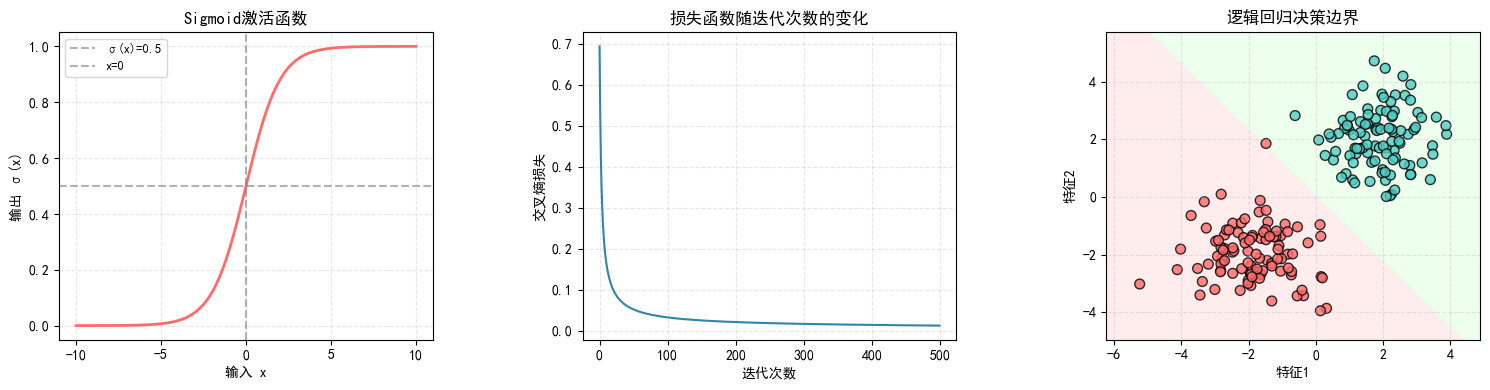

In [ ]:
# 手动实现逻辑回归
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号

class LogisticRegression:
    """逻辑回归模型实现"""
    
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def sigmoid(self, z):
        """sigmoid激活函数"""
        return 1 / (1 + np.exp(-z))
    
    def compute_loss(self, y, y_pred):
        """计算交叉熵损失"""
        # 防止log(0)的情况
        epsilon = 1e-10
        return -np.mean(y * np.log(y_pred + epsilon) + (1 - y) * np.log(1 - y_pred + epsilon))
    
    def fit(self, X, y):
        """训练模型"""
        n_samples, n_features = X.shape
        
        # 初始化参数
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # 梯度下降
        for i in range(self.num_iterations):
            # 计算线性输出
            linear_output = np.dot(X, self.weights) + self.bias
            # 应用sigmoid函数
            y_pred = self.sigmoid(linear_output)
            
            # 计算损失并保存
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)
            
            # 计算梯度
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            # 更新参数
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # 每100次迭代打印一次损失
            if i % 100 == 0:
                print(f"迭代 {i}/{self.num_iterations}, 损失: {loss:.4f}")
    
    def predict(self, X):
        """预测类别"""
        linear_output = np.dot(X, self.weights) + self.bias
        y_pred_proba = self.sigmoid(linear_output)
        y_pred = [1 if i > 0.5 else 0 for i in y_pred_proba]
        return np.array(y_pred), y_pred_proba

# 生成示例数据
def generate_data(n_samples=100):
    """生成用于逻辑回归的二分类数据"""
    np.random.seed(42)  # 设置随机种子，确保结果可复现
    
    # 生成两类数据
    # np.random.randn(n_samples, 2) 生成标准正态分布的形状为(n_samples, 2)的数组数据
    # + np.array([2, 2]) 和 + np.array([-2, -2]) 利用 numpy 的广播机制，将正态分布数据平移到不同位置
    class1 = np.random.randn(n_samples, 2) + np.array([2, 2])
    class0 = np.random.randn(n_samples, 2) + np.array([-2, -2])
    
    # 合并数据
    X = np.vstack((class1, class0)) # 垂直堆叠，形成形状为(2*n_samples, 2)的数组
    y = np.hstack((np.ones(n_samples), np.zeros(n_samples))) # 水平堆叠，形成形状为(2*n_samples,)的标签数组
    
    return X, y

def plot_loss_curve(ax, model):
    """在指定的子图上绘制损失曲线"""
    ax.plot(range(len(model.loss_history)), model.loss_history, color='#2E86AB')
    ax.set_title('损失函数随迭代次数的变化', fontsize=12)
    ax.set_xlabel('迭代次数', fontsize=10)
    ax.set_ylabel('交叉熵损失', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')

def plot_decision_boundary(ax, X, y, model):
    """在指定的子图上绘制决策边界"""
    # 设置网格范围
    h = 0.02  # 网格步长（控制决策边界平滑度）
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # 预测网格点的类别
    Z, _ = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 绘制决策边界
    cmap_light = ListedColormap(['#FFE6E6', '#E6FFE6'])  # 浅色背景（区分两类区域）
    cmap_bold = ListedColormap(['#FF6B6B', '#4ECDC4'])   # 深色散点（区分两类样本）
    
    # 绘制背景区域（按预测类别着色）
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.7)
    # 绘制样本散点
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=50, alpha=0.8)
    ax.set_title('逻辑回归决策边界', fontsize=12)
    ax.set_xlabel('特征1', fontsize=10)
    ax.set_ylabel('特征2', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')

def plot_sigmoid_function(ax):
    """在指定的子图上绘制sigmoid函数图像"""
    x = np.linspace(-10, 10, 200)  # 更多采样点，使曲线更平滑
    y = 1 / (1 + np.exp(-x))
    
    ax.plot(x, y, color='#FF6B6B', linewidth=2)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.6, label='σ(x)=0.5')
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.6, label='x=0')
    ax.set_title('Sigmoid激活函数', fontsize=12)
    ax.set_xlabel('输入 x', fontsize=10)
    ax.set_ylabel('输出 σ(x)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')

def main():
    # 生成数据
    X, y = generate_data(n_samples=100)
    
    # 训练模型
    model = LogisticRegression(learning_rate=0.1, num_iterations=500)
    model.fit(X, y)
    
    # 创建一个包含3个子图的图形，并排显示
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    
    # 1. 绘制sigmoid函数
    plot_sigmoid_function(ax1)
    
    # 2. 绘制损失曲线
    plot_loss_curve(ax2, model)
    
    # 3. 绘制决策边界
    plot_decision_boundary(ax3, X, y, model)
    
    # 调整子图之间的间距
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.4)  # 调整水平间距
    plt.show()

if __name__ == "__main__":
    main()


迭代 0/500, 损失: 0.6931
迭代 100/500, 损失: 0.0321
迭代 200/500, 损失: 0.0208
迭代 300/500, 损失: 0.0163
迭代 400/500, 损失: 0.0138


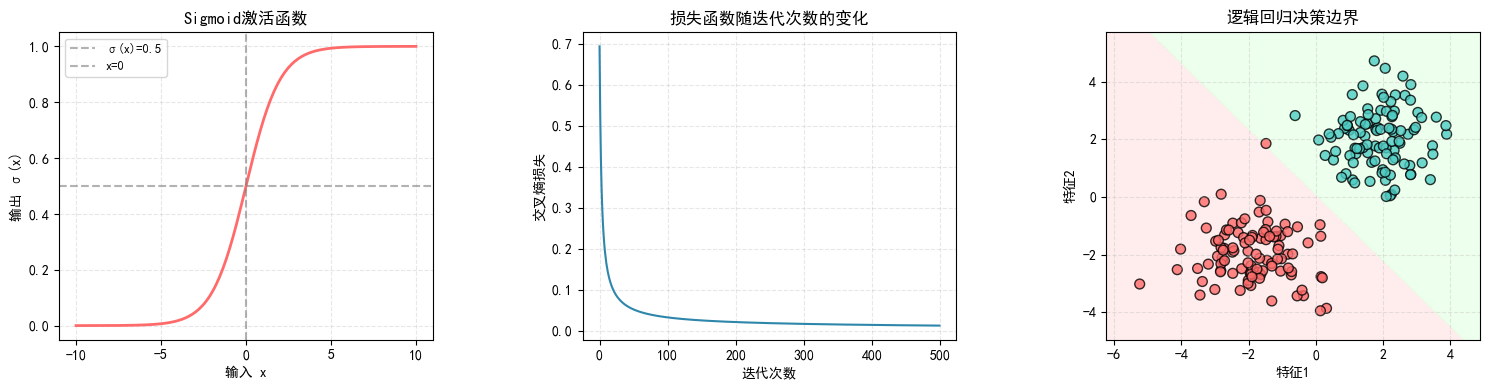

In [ ]:
# pytorch实现逻辑回归
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import torch
import torch.nn as nn
import torch.optim as optim

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号

class LogisticRegression(nn.Module):
    """PyTorch逻辑回归模型实现"""
    
    def __init__(self, input_dim, learning_rate=0.01):
        super(LogisticRegression, self).__init__()
        # 定义线性层: y = wx + b
        self.linear = nn.Linear(input_dim, 1)
        # 初始化参数
        nn.init.zeros_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)
        
        # 优化器
        self.optimizer = optim.SGD(self.parameters(), lr=learning_rate)
        # 损失函数: 二元交叉熵
        self.criterion = nn.BCELoss()
        
        self.loss_history = []
    
    def forward(self, x):
        """前向传播"""
        # 线性输出后应用sigmoid激活函数
        out = torch.sigmoid(self.linear(x))
        return out
    
    def fit(self, X, y, num_iterations=1000):
        """训练模型"""
        # 将numpy数组转换为PyTorch张量
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)  # 调整形状以匹配输出
        
        # 梯度下降
        for i in range(num_iterations):
            # 前向传播
            y_pred = self.forward(X_tensor)
            
            # 计算损失并保存
            loss = self.criterion(y_pred, y_tensor)
            self.loss_history.append(loss.item())
            
            # 反向传播和参数更新
            self.optimizer.zero_grad()  # 清零梯度
            loss.backward()             # 反向传播计算梯度
            self.optimizer.step()       # 更新参数
            
            # 每100次迭代打印一次损失
            if i % 100 == 0:
                print(f"迭代 {i}/{num_iterations}, 损失: {loss.item():.4f}")
    
    def predict(self, X):
        """预测类别"""
        # 转换为张量并设置为评估模式
        X_tensor = torch.tensor(X, dtype=torch.float32)
        self.eval()
        
        # 不计算梯度进行预测
        with torch.no_grad():
            y_pred_proba = self.forward(X_tensor)
        
        # 转换回numpy并确定类别
        y_pred_proba_np = y_pred_proba.numpy().flatten()
        y_pred = (y_pred_proba_np > 0.5).astype(int)
        
        return y_pred, y_pred_proba_np

# 生成示例数据
def generate_data(n_samples=100):
    """生成用于逻辑回归的二分类数据"""
    np.random.seed(42)  # 设置随机种子，确保结果可复现
    
    # 生成两类数据
    class1 = np.random.randn(n_samples, 2) + np.array([2, 2])
    class0 = np.random.randn(n_samples, 2) + np.array([-2, -2])
    
    # 合并数据
    X = np.vstack((class1, class0))
    y = np.hstack((np.ones(n_samples), np.zeros(n_samples)))
    
    return X, y

def plot_loss_curve(ax, model):
    """在指定的子图上绘制损失曲线"""
    ax.plot(range(len(model.loss_history)), model.loss_history, color='#2E86AB')
    ax.set_title('损失函数随迭代次数的变化', fontsize=12)
    ax.set_xlabel('迭代次数', fontsize=10)
    ax.set_ylabel('交叉熵损失', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')

def plot_decision_boundary(ax, X, y, model):
    """在指定的子图上绘制决策边界"""
    # 设置网格范围
    h = 0.02  # 网格步长（控制决策边界平滑度）
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # 预测网格点的类别
    Z, _ = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 绘制决策边界
    cmap_light = ListedColormap(['#FFE6E6', '#E6FFE6'])  # 浅色背景（区分两类区域）
    cmap_bold = ListedColormap(['#FF6B6B', '#4ECDC4'])   # 深色散点（区分两类样本）
    
    # 绘制背景区域（按预测类别着色）
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.7)
    # 绘制样本散点
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=50, alpha=0.8)
    ax.set_title('逻辑回归决策边界', fontsize=12)
    ax.set_xlabel('特征1', fontsize=10)
    ax.set_ylabel('特征2', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')

def plot_sigmoid_function(ax):
    """在指定的子图上绘制sigmoid函数图像"""
    x = np.linspace(-10, 10, 200)  # 更多采样点，使曲线更平滑
    y = 1 / (1 + np.exp(-x))
    
    ax.plot(x, y, color='#FF6B6B', linewidth=2)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.6, label='σ(x)=0.5')
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.6, label='x=0')
    ax.set_title('Sigmoid激活函数', fontsize=12)
    ax.set_xlabel('输入 x', fontsize=10)
    ax.set_ylabel('输出 σ(x)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')

def main():
    # 生成数据
    X, y = generate_data(n_samples=100)
    
    # 获取特征维度
    input_dim = X.shape[1]
    
    # 训练模型
    model = LogisticRegression(input_dim=input_dim, learning_rate=0.1)
    model.fit(X, y, num_iterations=500)
    
    # 创建一个包含3个子图的图形，并排显示
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    
    # 1. 绘制sigmoid函数
    plot_sigmoid_function(ax1)
    
    # 2. 绘制损失曲线
    plot_loss_curve(ax2, model)
    
    # 3. 绘制决策边界
    plot_decision_boundary(ax3, X, y, model)
    
    # 调整子图之间的间距
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.4)  # 调整水平间距
    plt.show()

if __name__ == "__main__":
    main()



模型参数:
偏置 b = -0.35
权重 w = [[1.93 1.51]]


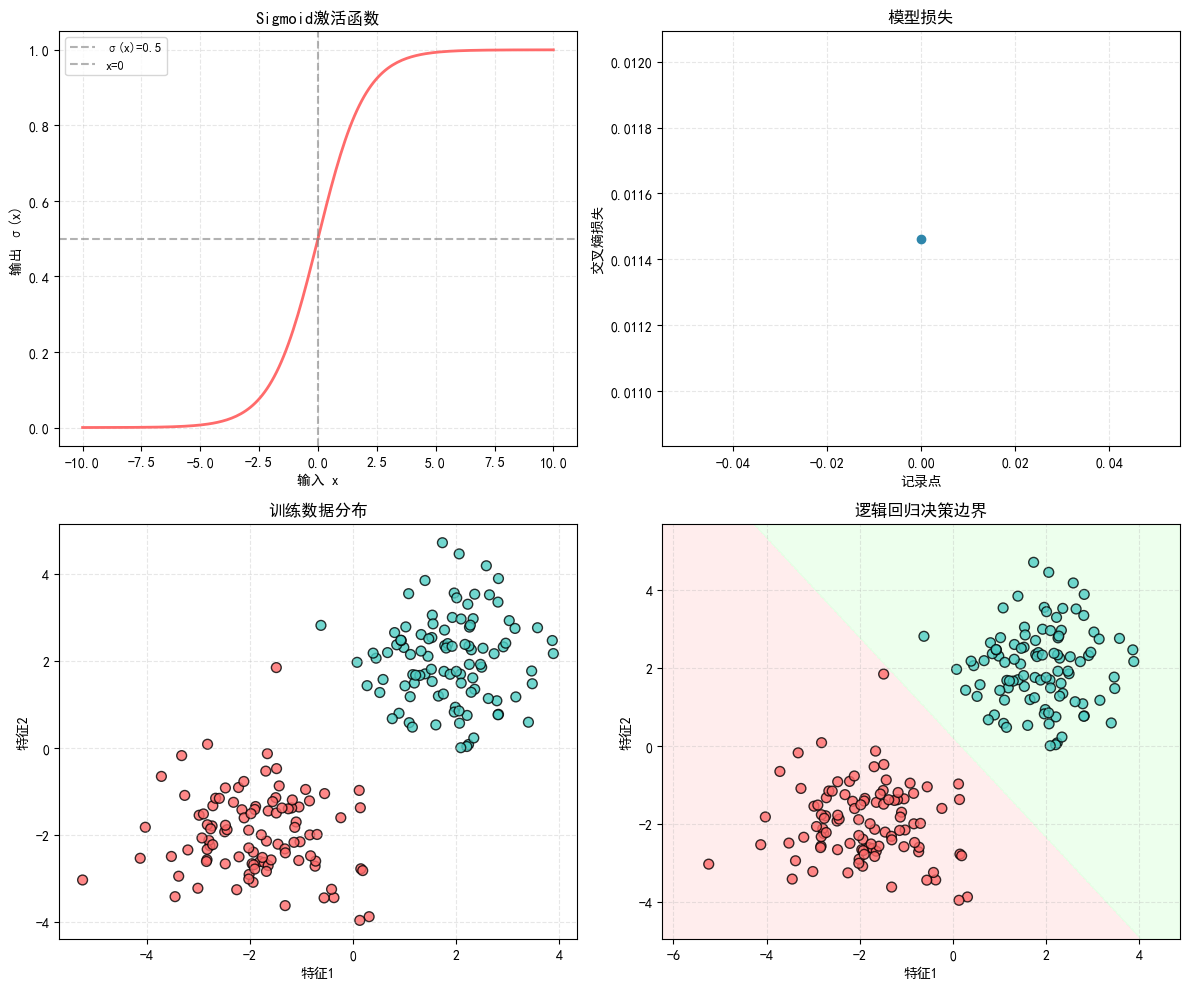

In [ ]:
# 用sklearn实现逻辑回归
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, log_loss
from matplotlib.colors import ListedColormap

# 设置打印精度
np.set_printoptions(precision=2)

# 定义颜色
dlblue = '#0096ff'; dlorange = '#FF9300'; dldarkred='#C00000'; 
dlmagenta='#FF40FF'; dlpurple='#7030A0'; 

# 自定义逻辑回归类，记录损失历史
class CustomLogisticRegression(LogisticRegression):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.loss_history = []
    
    def fit(self, X, y, sample_weight=None):
        # 调用父类的fit方法
        super().fit(X, y, sample_weight)
        
        # 计算并记录训练过程中的损失（这里使用最终模型的损失）
        y_pred = self.predict_proba(X)
        loss = log_loss(y, y_pred)
        self.loss_history = [loss]  # !!!由于sklearn不提供迭代历史，这里只记录最终损失
        
        return self

# 生成示例数据
def generate_data(n_samples=100):
    """生成用于逻辑回归的二分类数据"""
    np.random.seed(42)  # 设置随机种子，确保结果可复现
    
    # 生成两类数据
    class1 = np.random.randn(n_samples, 2) + np.array([2, 2])
    class0 = np.random.randn(n_samples, 2) + np.array([-2, -2])
    
    # 合并数据
    X = np.vstack((class1, class0))
    y = np.hstack((np.ones(n_samples), np.zeros(n_samples)))
    
    return X, y

def plot_loss_curve(ax, model):
    """在指定的子图上绘制损失曲线"""
    if hasattr(model, 'loss_history') and model.loss_history:
        ax.plot(range(len(model.loss_history)), model.loss_history, color='#2E86AB', marker='o')
        ax.set_title('模型损失', fontsize=12)
        ax.set_xlabel('记录点', fontsize=10)
        ax.set_ylabel('交叉熵损失', fontsize=10)
        ax.grid(True, alpha=0.3, linestyle='--')
    else:
        ax.text(0.5, 0.5, '无损失历史数据', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('模型损失', fontsize=12)

def plot_decision_boundary(ax, X, y, model):
    """在指定的子图上绘制决策边界"""
    # 设置网格范围
    h = 0.02  # 网格步长
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # 预测网格点的类别
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 绘制决策边界
    cmap_light = ListedColormap(['#FFE6E6', '#E6FFE6'])
    cmap_bold = ListedColormap(['#FF6B6B', '#4ECDC4'])
    
    # 绘制背景区域
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.7)
    # 绘制样本散点
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=50, alpha=0.8)
    ax.set_title('逻辑回归决策边界', fontsize=12)
    ax.set_xlabel('特征1', fontsize=10)
    ax.set_ylabel('特征2', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')

def plot_sigmoid_function(ax):
    """在指定的子图上绘制sigmoid函数图像"""
    x = np.linspace(-10, 10, 200)
    y = 1 / (1 + np.exp(-x))
    
    ax.plot(x, y, color='#FF6B6B', linewidth=2)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.6, label='σ(x)=0.5')
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.6, label='x=0')
    ax.set_title('Sigmoid激活函数', fontsize=12)
    ax.set_xlabel('输入 x', fontsize=10)
    ax.set_ylabel('输出 σ(x)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')

def plot_training_data(ax, X, y):
    """绘制训练数据分布"""
    cmap_bold = ListedColormap(['#FF6B6B', '#4ECDC4'])
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=50, alpha=0.8)
    ax.set_title('训练数据分布', fontsize=12)
    ax.set_xlabel('特征1', fontsize=10)
    ax.set_ylabel('特征2', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')

def main():
    # 生成数据
    X, y = generate_data(n_samples=100)
    
    # 使用自定义的逻辑回归模型
    model = CustomLogisticRegression()
    model.fit(X, y)
  
    # 获取模型参数
    b = model.intercept_
    w = model.coef_
    
    if isinstance(b, np.ndarray):
        b = b[0]

    print(f"\n模型参数:")
    print(f"偏置 b = {b:.2f}")
    print(f"权重 w = {w}")

    # 创建一个包含4个子图的图形
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
    
    # 1. 绘制sigmoid函数
    plot_sigmoid_function(ax1)
    
    # 2. 绘制损失曲线
    plot_loss_curve(ax2, model)
    
    # 3. 绘制训练数据
    plot_training_data(ax3, X, y)
    
    # 4. 绘制决策边界
    plot_decision_boundary(ax4, X, y, model)
    
    # 调整子图之间的间距
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()